In [14]:
import time
import pickle

In [15]:
%load_ext autoreload
%autoreload 2
import os
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, travel_time, hex_manhattan_distance, f_cost, construct_full_solution, radius_from_angle, next_velocity
from hexgrid import (HexCoord, build_obstacle_map, HexGrid, Node, get_direction, 
    VelocityState, get_neighbors_at_radius, get_available_nodes_in_dir, get_direction_ray, 
    hex_segment_between, hdist, angle_abc, image_to_hex_obstacles, 
    unique_direction_vectors_up_to_n, circular_slice, add_coords)
from hexplot import plot_hex_grid
from typing import Iterable, Optional, Set, List, Tuple, Callable, Dict
import math

In [17]:
RADIUS = 200
MAP_JPG_SIZE = 600 # largest dimension in px
a_max = 9.8
a_min = 1
ay_window_ms = 10

collision_radius = 0

jps_horizon = None
n_step = 8

In [18]:
maps_dir = "maps"

maps = [
    'r3h0.33.pkl',
    'r15h1.00.pkl',
    'r30h5.00.pkl',
    'r40h5.00.pkl',
    'r50h5.00.pkl'
]

In [19]:
def save_layout(layout, filename):
    with open(filename, 'wb') as file:
        pickle.dump(layout, file)

def load_layout(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)

In [20]:
m = maps[5]
hex_layout = load_layout(maps_dir +"/"+ m)

IndexError: list index out of range

In [21]:
obs = hex_layout['obstacle_map']
hex_size = hex_layout['hex_size']
radius = hex_layout['hex_radius']

In [22]:
def tup_to_hexcoord(tup):
    return HexCoord(tup[0], tup[1])

In [10]:
start = tup_to_hexcoord(hex_layout['agent'])
goal = tup_to_hexcoord(hex_layout['goal'])

obs = {tup_to_hexcoord(t) for t in obs}
border = get_neighbors_at_radius(HexCoord(0,0), radius+1)

hg = HexGrid(hex_size, obs.union(border))

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    #goal_v = VelocityState(0, None)
)
#problem.goal_v=VelocityState(0, problem.DIRECTIONS.index(HexCoord(-1,2))) # approach from the northeast
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

<Axes: title={'center': 'Hex grid (radius=51) centered at center=(0,0)  Run 1 REVERSE'}, xlabel='x', ylabel='y'>

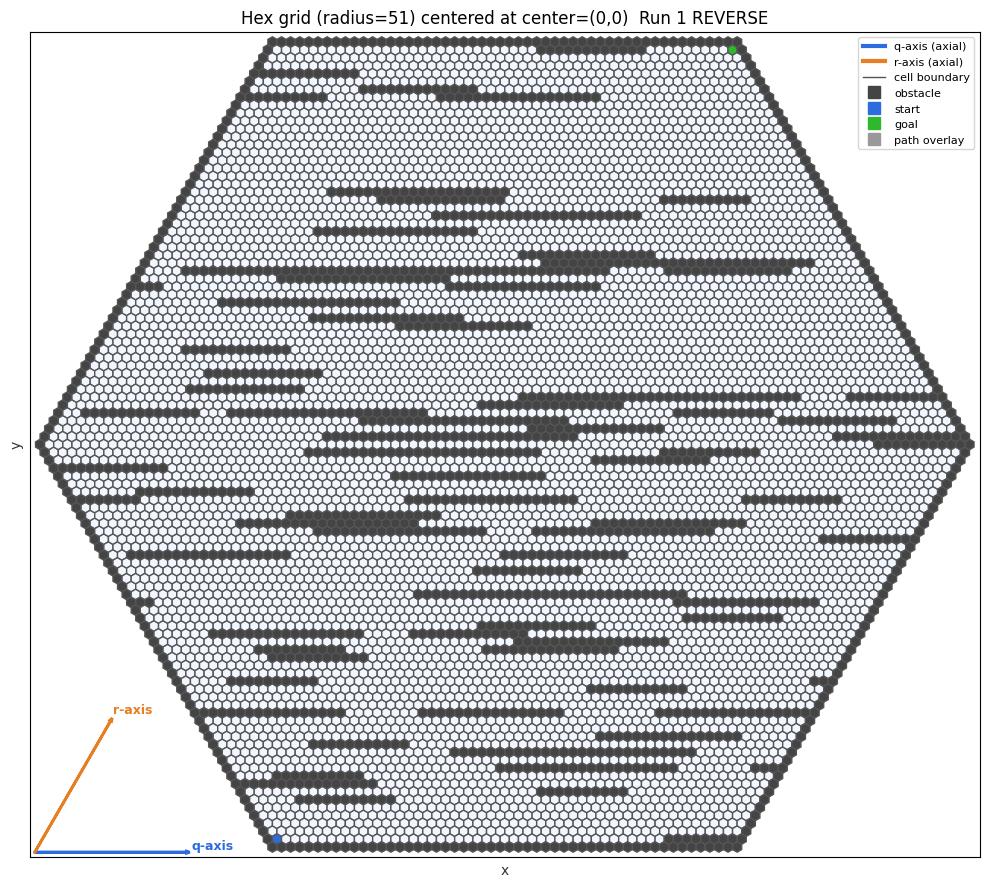

In [11]:
plot_hex_grid(
    hg.obstacles,
    start,
    HexCoord(0,0),
    radius+1,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = hexes_in_between_solid(HexCoord(q=0, r=0), HexCoord(q=14, r=10)),
    #path=problem.get_available_hexes_in_dir(start, problem.DIRECTIONS[0], ray_range = 50),
    #path=problem.actions(hs.root),
    #path=set(unique_direction_vectors_up_to_n(HexCoord(0,0), RADIUS)),
    facecolor_path = "#999999",
    #path = set([n.location for n in fsolution[-24:-21]]),
    #path = fsolution,
    linewidth=1,
    plt_title = f" Run {1} REVERSE",
    #save_path=f"n-step-actions-jps",
)

In [12]:
fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)

<Axes: title={'center': 'Hex grid (radius=51) centered at center=(0,0) Solution'}, xlabel='x', ylabel='y'>

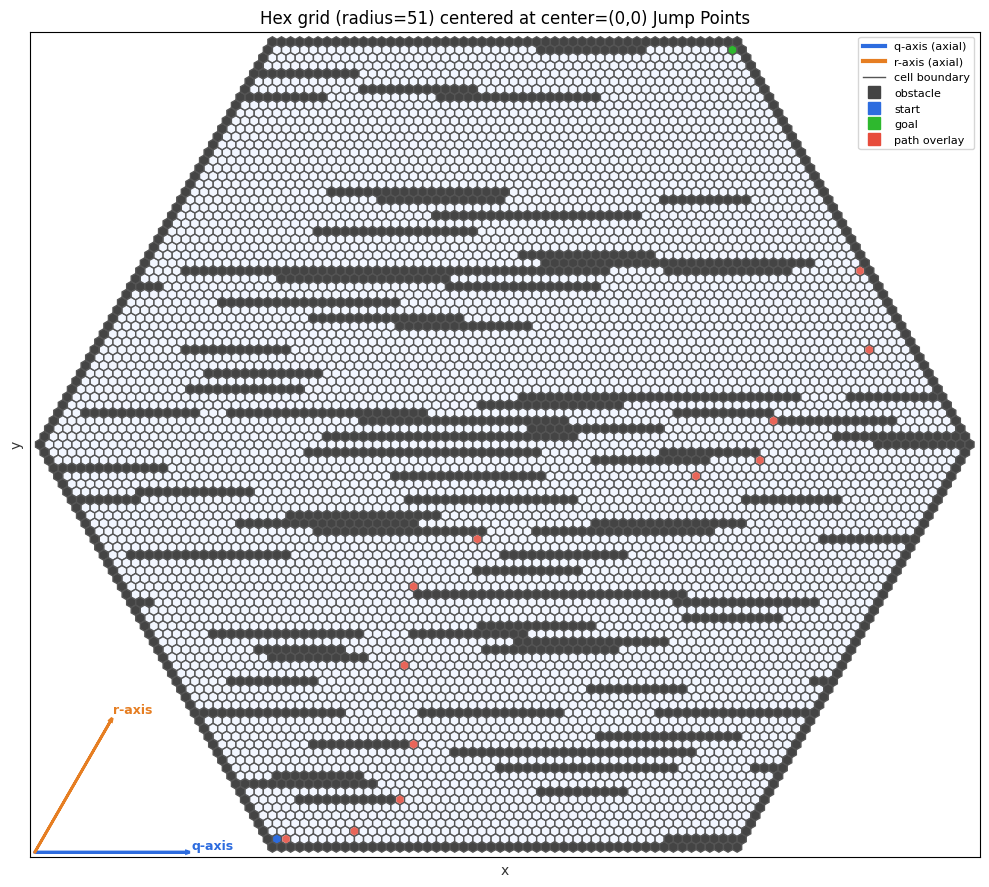

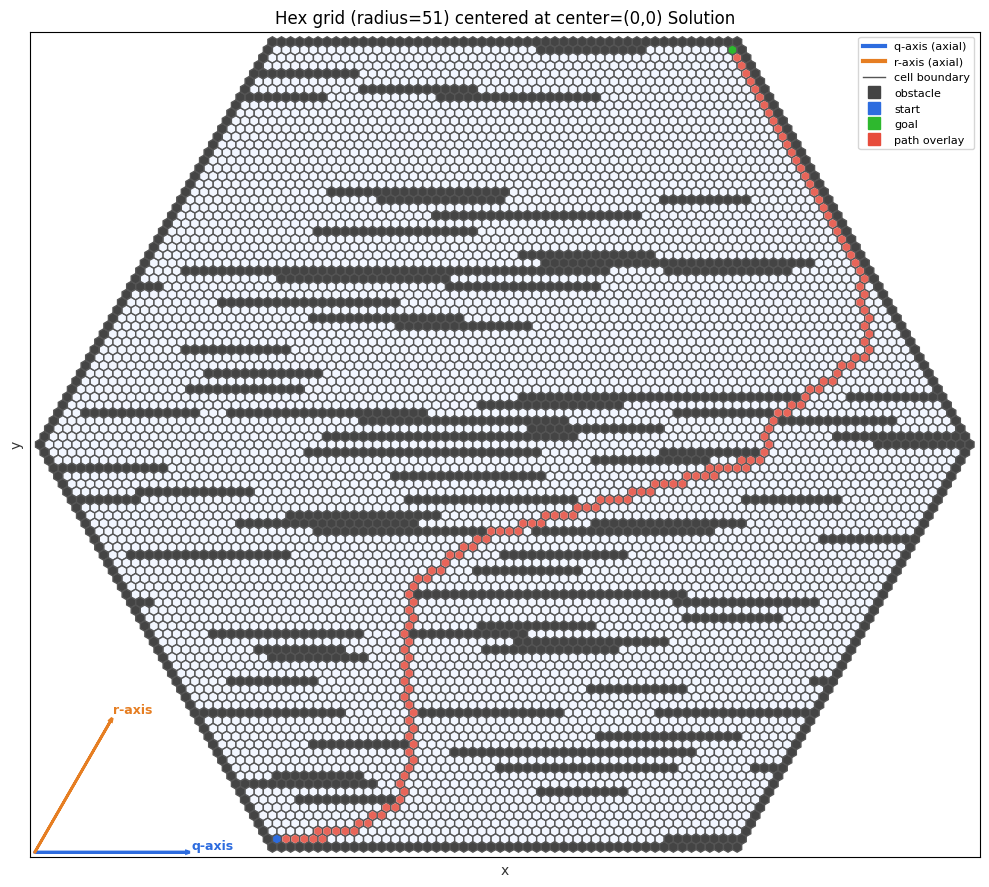

In [13]:
plot_hex_grid(
    hg.obstacles,
    start,
    HexCoord(0,0),
    radius+1,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=1,
    plt_title = f"Jump Points",
    #save_path=f"jump-points-turning-r",
)
plot_hex_grid(
    hg.obstacles,
    start,
    HexCoord(0,0),
    radius+1,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=1,
    plt_title = f"Solution",
    #save_path=f"solution-turning-r",
)

In [ ]:
# Dictionaries to store the data
states_data = {}
nodes_data = {}
branching_data = {}
depths_data = {}
problems = {}
solutions = {}

# Heuristic functions to use
#heuristics = [zero_heuristic, box_goal_euclidian_distance, box_goal_manhattan_distance]

maps = [
    'r3h0.33.pkl',
    'r15h1.00.pkl',
    'r30h5.00.pkl',
    'r40h5.00.pkl',
    'r50h5.00.pkl'
]

for m in maps:
    print(f"Processing map file: {m}\n")
    states_expanded = []
    nodes_generated = []
    eff_branching_factors = []
    depths = []
    
        

    # Start the timer
    start = time.time()

    # Execute the search
    problem, solution = solve(maps_dir +"/"+ m)

    # Stop the timer
    end = time.time()

    # If a solution was found
    if solution is not None:
        consistent, states, nodes = problem.get_benchmarks()
        solution_cost = solution.path_cost
        states_expanded.append(states)
        nodes_generated.append(nodes)
        depths.append(solution_cost)

        current_node = solution
        solution_path = []
        while current_node.parent is not None:
            # print(current_node.state)
            # print(current_node.path_cost)
            loc, v = current_node.state
            cost = current_node.path_cost
            solution_path.append(loc)
            #velocities.append(v)
            #path_costs.append(cost)
            current_node = current_node.parent
            
        
        solution_path = list(reversed(solution_path))
        #velocities = list(reversed(velocities))
        #path_costs = list(reversed(path_costs))
        eff_branch_factor = pow(nodes, 1/len(solution_path))
        eff_branching_factors.append(eff_branch_factor)
        plot_problem(problem, solution_path)
    else:
        solution_cost = None
        eff_branch_factor = None
    print(f"Solution depth {len(solution_path)} found in {end-start} seconds\nExplored {nodes} states.")
    if not consistent:
        print(f"Test case {m} has shown the heuristic is not consistent")
    states_data[m] = states_expanded
    nodes_data[m] = nodes_generated
    branching_data[m] = eff_branching_factors
    depths_data[m] = depths
    problems[m] = problem
    solutions[m] = solution

In [ ]:
states_data

In [ ]:
nodes_data

In [ ]:
branching_data

In [ ]:
depths_data